<a href="https://colab.research.google.com/github/annanyak12/Student-Dropout-Prediction/blob/main/drop_out_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/new_dataset.csv")
df.head()

,student_id,Gender,gpa_current,attendance_rate,Financial_aid_status,Family_Income,Dropout
0,S1000,Female,4.02,0.79,False,377939,1
1,S1001,Male,3.49,0.54,True,295213,1
2,S1002,Male,3.10,0.33,False,937175,2
3,S1003,Male,3.58,0.97,False,156562,2
4,S1004,Female,4.21,0.56,False,749328,1


In [ ]:
df.shape

(4000, 7)

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            4000 non-null   object 
 1   Gender                4000 non-null   object 
 2   gpa_current           4000 non-null   float64
 3   attendance_rate       4000 non-null   float64
 4   Financial_aid_status  4000 non-null   bool   
 5   Family_Income         4000 non-null   int64  
 6   Dropout               4000 non-null   int64  
dtypes: bool(1), float64(2), int64(2), object(2)
memory usage: 191.5+ KB
None


In [ ]:
df["Financial_aid_status"] = df["Financial_aid_status"].astype(int)

In [ ]:
columns = ('Gender','Financial_aid_status')
for col in columns:
  print(f"Unique values in {col}:")
  print(df[col].unique())
  print()

Unique values in Gender:
['Female' 'Male']

Unique values in Financial_aid_status:
[0 1]



In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])


# **DATA VISUALISATION**

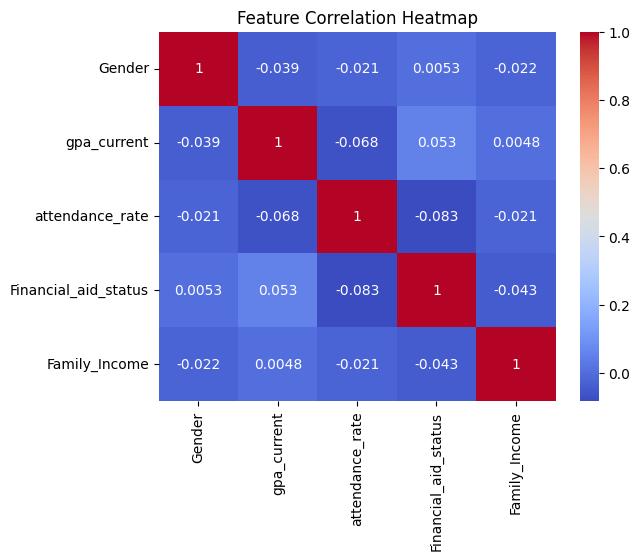

In [ ]:
import seaborn as sns
selected = ['Gender', 'gpa_current', 'attendance_rate', 'Financial_aid_status', 'Family_Income']
corr = df[selected].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


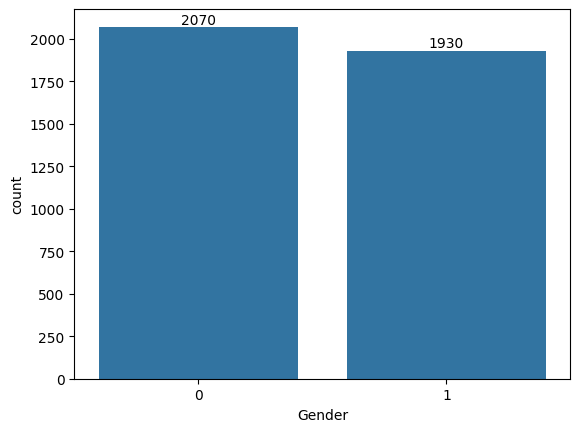

In [ ]:
ax = sns.countplot(x= 'Gender', data = df)
for bars in ax.containers:
  ax.bar_label(bars)

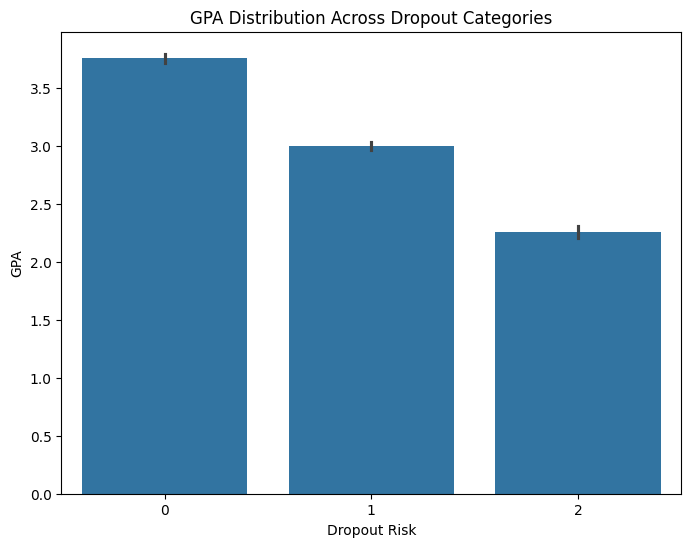

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.barplot(x="Dropout", y="gpa_current", data=df, order=["0","1","2"])
plt.title("GPA Distribution Across Dropout Categories")
plt.xlabel("Dropout Risk")
plt.ylabel("GPA")
plt.show()


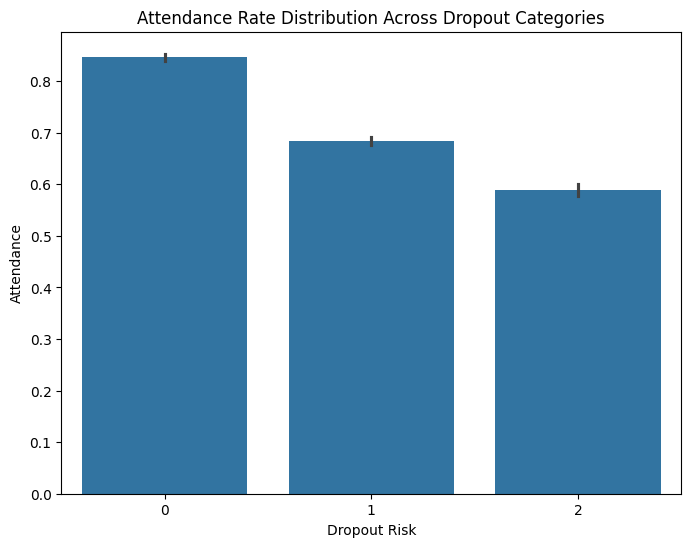

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(x="Dropout", y="attendance_rate", data=df, order=["0","1","2"])
plt.title("Attendance Rate Distribution Across Dropout Categories")
plt.xlabel("Dropout Risk")
plt.ylabel("Attendance")
plt.show()

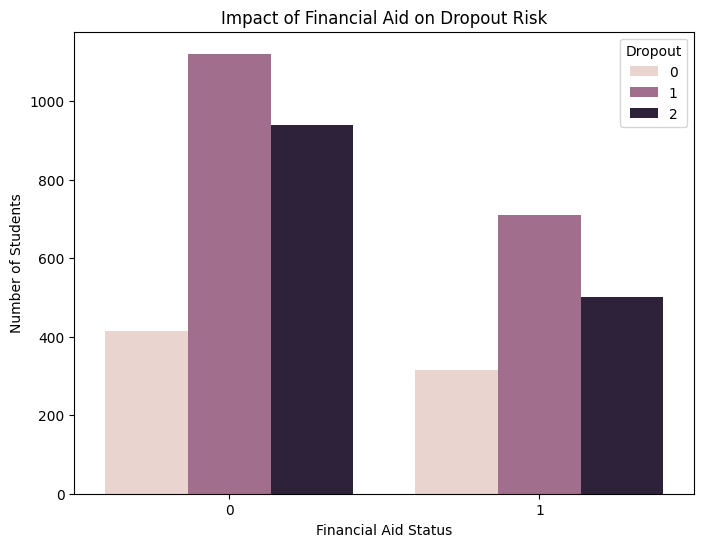

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x="Financial_aid_status", hue="Dropout", data=df)
plt.title("Impact of Financial Aid on Dropout Risk")
plt.xlabel("Financial Aid Status")
plt.ylabel("Number of Students")
plt.show()


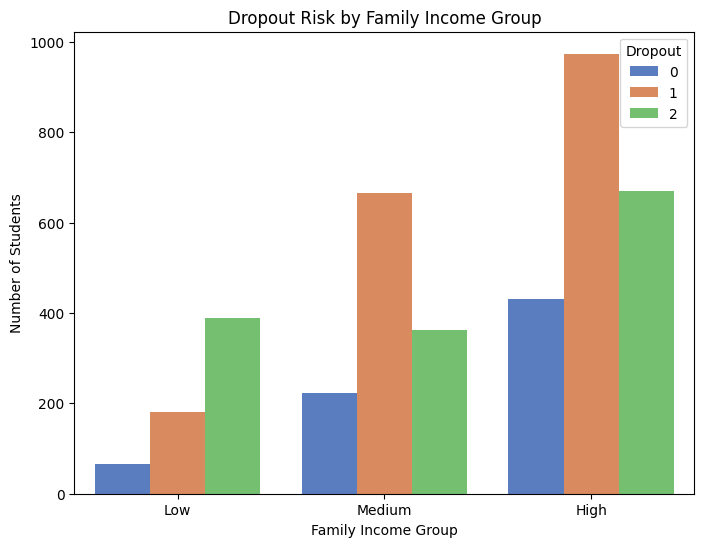

In [ ]:
df['IncomeGroup'] = pd.cut(df['Family_Income'], bins=[0,200000,500000,1000000],
                           labels=['Low','Medium','High'])

plt.figure(figsize=(8,6))
sns.countplot(x="IncomeGroup", hue="Dropout", data=df, palette="muted")
plt.title("Dropout Risk by Family Income Group")
plt.xlabel("Family Income Group")
plt.ylabel("Number of Students")
plt.show()


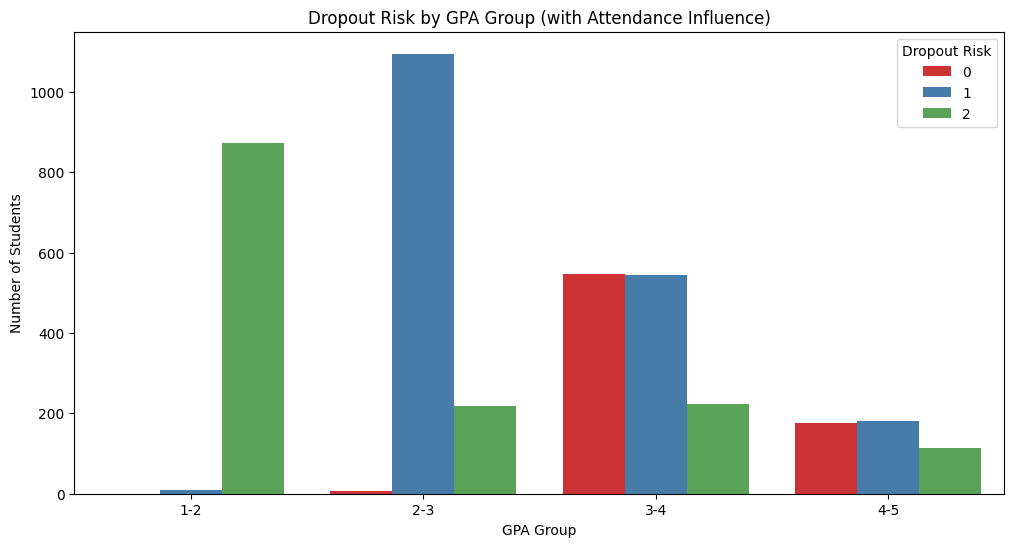

In [ ]:
df["GPA_Group"] = pd.cut(df["gpa_current"], bins=[1,2,3,4,5], labels=["1-2","2-3","3-4","4-5"])
df["Attendance_Group"] = pd.cut(df["attendance_rate"], bins=[0.2,0.5,0.8,1.0], labels=["Low","Medium","High"])

plt.figure(figsize=(12,6))
sns.countplot(x="GPA_Group", hue="Dropout", data=df, dodge=True, palette="Set1")
plt.title("Dropout Risk by GPA Group (with Attendance Influence)")
plt.xlabel("GPA Group")
plt.ylabel("Number of Students")
plt.legend(title="Dropout Risk")
plt.show()


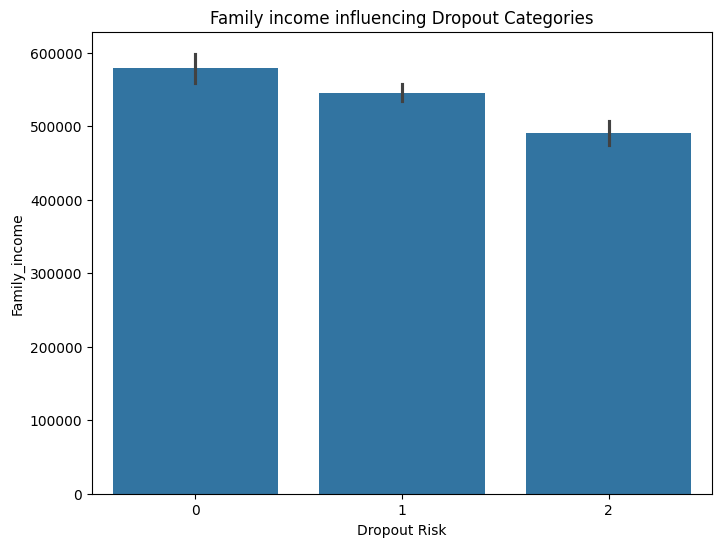

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(x="Dropout", y="Family_Income", data=df, order=["0","1","2"])
plt.title("Family income influencing Dropout Categories")
plt.xlabel("Dropout Risk")
plt.ylabel("Family_income")
plt.show()


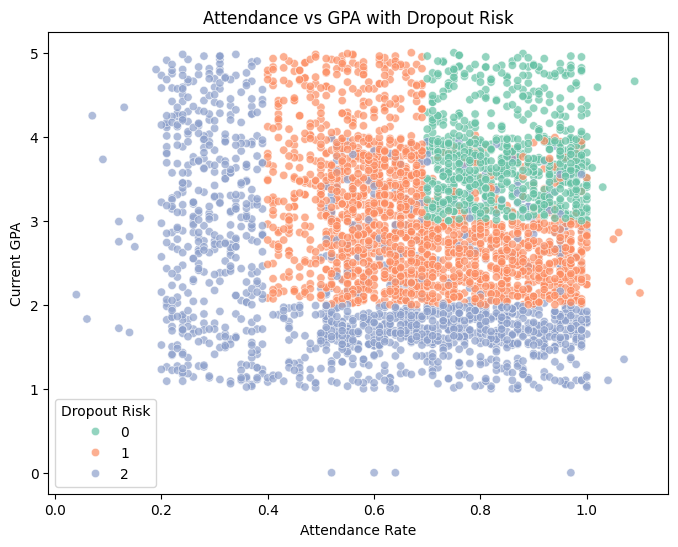

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="attendance_rate", y="gpa_current", hue="Dropout", data=df, palette="Set2", alpha=0.7)
plt.title("Attendance vs GPA with Dropout Risk")
plt.xlabel("Attendance Rate")
plt.ylabel("Current GPA")
plt.legend(title="Dropout Risk")
plt.show()


## **TRAINING AND TESTING**

In [ ]:
df.drop(['GPA_Group', 'Attendance_Group', 'IncomeGroup'], axis=1, inplace=True)

In [ ]:
df.head()

,student_id,Gender,gpa_current,attendance_rate,Financial_aid_status,Family_Income,Dropout
0,S1000,0,4.02,0.79,0,377939,1
1,S1001,1,3.49,0.54,1,295213,1
2,S1002,1,3.10,0.33,0,937175,2
3,S1003,1,3.58,0.97,0,156562,2
4,S1004,0,4.21,0.56,0,749328,1


In [ ]:
X = df.iloc[:,1:-1]
y = df.iloc[:, -1]
print(X.shape)
print(y.shape)

(4000, 5)
(4000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size= 0.2, random_state = 0)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [ ]:
y_prediction = rf_model.predict(X_test)

In [ ]:
cm = confusion_matrix(y_test, y_prediction)
print("Confusion matrix:\n", cm)

Confusion matrix:
 [[154   0   5]
 [ 16 326  13]
 [  0   0 286]]


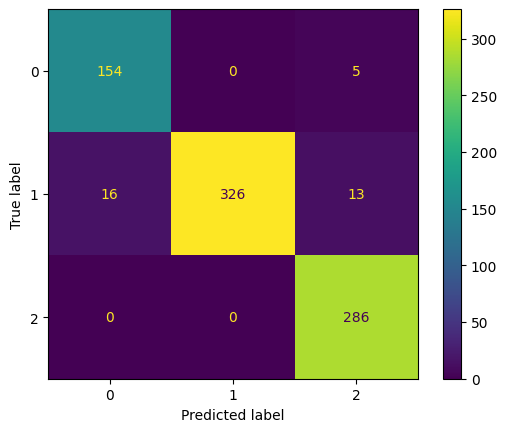

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_prediction))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       159
           1       1.00      0.92      0.96       355
           2       0.94      1.00      0.97       286

    accuracy                           0.96       800
   macro avg       0.95      0.96      0.95       800
weighted avg       0.96      0.96      0.96       800



In [ ]:
print("Train Accuracy:",rf_model.score(X_train, y_train))
print("Test Accuracy:", rf_model.score(X_test, y_test))

Train Accuracy: 0.9721875
Test Accuracy: 0.9575


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y, cv=5)  # 5-fold cross-validation
print("Cross-validation scores:", scores)
print("Mean CV accuracy:", scores.mean())


Cross-validation scores: [0.9225  0.93625 0.97    0.9525  0.9525 ]
Mean CV accuracy: 0.9467500000000001


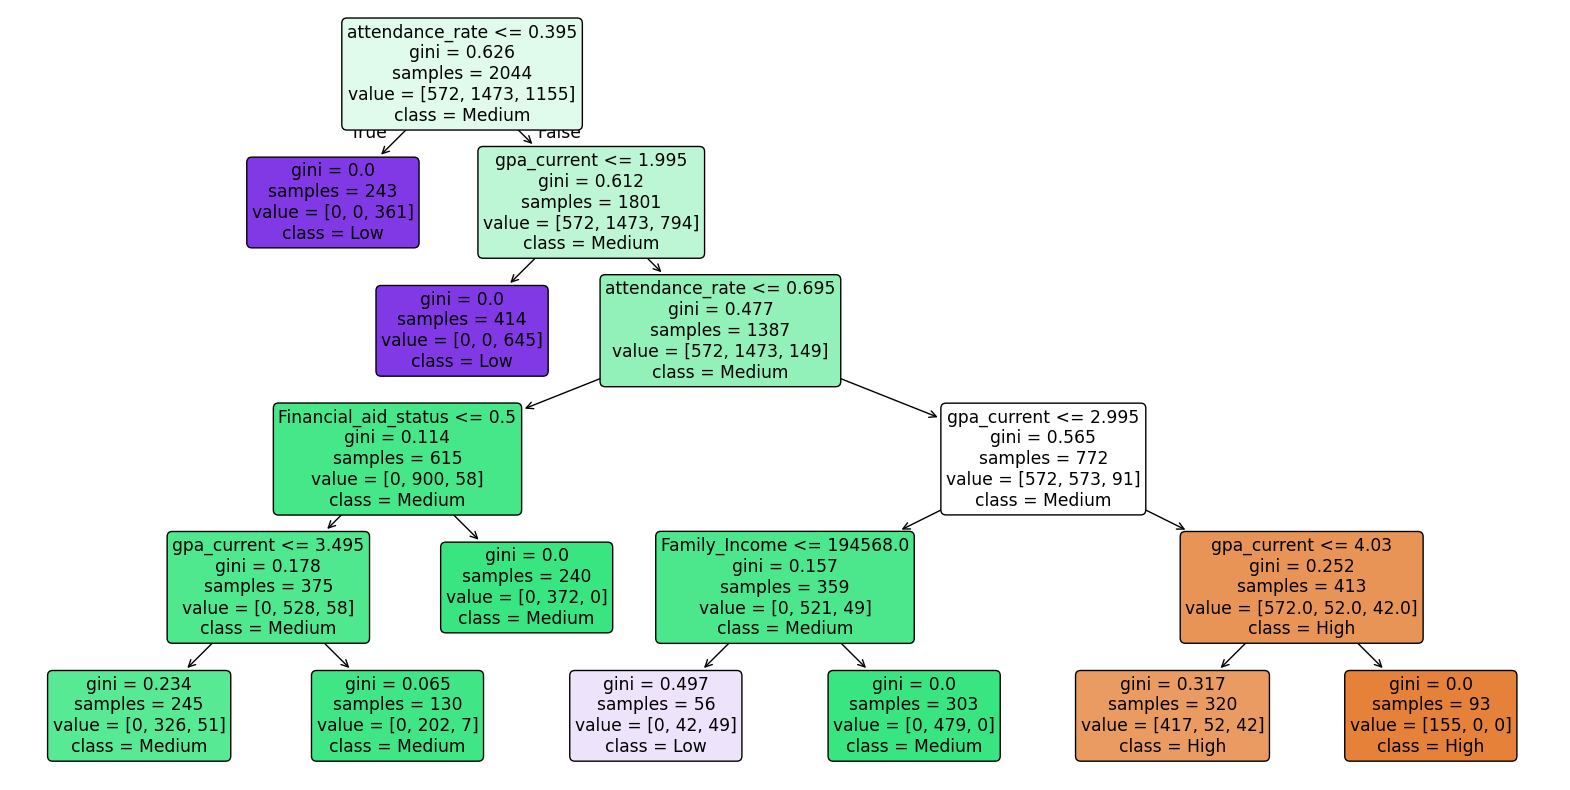

In [ ]:
from sklearn.tree import export_graphviz
import graphviz
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

#first tree in the forest
estimator = rf_model.estimators_[0]

# Plot the tree
plt.figure(figsize=(20,10))
plot_tree(estimator,
          feature_names=X.columns,
          class_names=["High", "Medium", "Low"],
          filled=True,
          rounded=True)
plt.show()

In [ ]:
df.head()

,student_id,Gender,gpa_current,attendance_rate,Financial_aid_status,Family_Income,Dropout
0,S1000,0,4.02,0.79,0,377939,1
1,S1001,1,3.49,0.54,1,295213,1
2,S1002,1,3.10,0.33,0,937175,2
3,S1003,1,3.58,0.97,0,156562,2
4,S1004,0,4.21,0.56,0,749328,1


# **Saving & Testing The Model**

In [ ]:
import pickle
with open('dropout_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)


In [ ]:
sample_student = pd.DataFrame([{
    'Gender': 0,  # Female (assuming 1 = Female)
    'gpa_current': 2.2,  # Low GPA
    'attendance_rate': 0.48,  # Very low attendance
    'Financial_aid_status': 0,  # Not approved
    'Family_Income': 65000  # Low income
}])

In [ ]:
import pickle

with open('dropout_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [ ]:
# Using it on new data
prediction = loaded_model.predict(sample_student)
print("Prediction from saved model:", prediction[0])

Prediction from saved model: 2


In [ ]:
sample_student['Financial_aid_status'] = 1

In [ ]:
rf_model.predict_proba(sample_student)[0]


array([0.00913015, 0.43650349, 0.55436636])

In [ ]:
low_risk_student = pd.DataFrame([{
    'Gender': 1,  # Female (assuming 1 = Female)
    'gpa_current': 8.2,  # Strong GPA
    'attendance_rate': 0.88,  # High attendance
    'Financial_aid_status': 1,  # Approved
    'Family_Income': 320000  # High income
}])


In [ ]:
pred = loaded_model.predict(low_risk_student)
print("Prediction from saved model:", pred[0])

Prediction from saved model: 0


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/practice.csv")

In [ ]:
df = df[['Gender','gpa_current','attendance_rate','Financial_aid_status','Family_Income']]

In [ ]:
df.head()

,Gender,gpa_current,attendance_rate,Financial_aid_status,Family_Income
0,Female,1.66,0.79,False,563441
1,Female,3.98,0.92,False,848045
2,Male,2.48,0.93,False,603709
3,Male,3.14,0.73,True,228338
4,Female,2.60,0.97,False,297272


In [ ]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df["Financial_aid_status"] = df["Financial_aid_status"].astype(int)

In [ ]:
predictions = loaded_model.predict(df)
df['Prediction'] = predictions
df.to_csv('predicted_output.csv', index=False)

In [ ]:
from google.colab import files
files.download('predicted_output.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>